# Imports

In [504]:
from pathlib import Path
import sys
import json
import importlib
import helpers_detection
print(helpers_detection.__file__)
helpers_detection = importlib.reload(helpers_detection)

from helpers_detection import *

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


c:\Users\eva\Documents\Master\ICM\Ilo\helpers_detection.py


# Global variables
- `DATA_ROOT`: Path to the folder containing patient's data (modify if needeed)
- `SUBJECT: TT001 is the initially selected subject because we already have its csv file `TT001_events`
- `CHANNEL`: EMG channel to analyze
- `BASELINE_WINDOW_S`: Number of seconds taken into account to compute the rolling baseline
- `K_HIGH`: Factor used to compute the upper threshold, high enough to limit the number of false positives.
- `K_LOW`: Factor used to compute the lower threshold, low values because the force drops below the baseline after most events.
- `MIN_DURATION`: Minimal duration between the upper threshold and the lower threshold crossings for an event to be recorded
- `MAX_DURATION`: Maximal duration between the upper threshold and the lower threshold crossings for an event to be recorded
- `REFRACTORY`: Number of seconds following an event during which a new event cannot be recorded

Adaptive high-threshold floor (bidirectional, resets every session -- see `detect_presses`):
- `FLOOR_MAX`: Starting/ceiling value of the floor at the beginning of each session (was the old fixed `HIGH_FLOOR`).
- `FLOOR_MIN`: Floor never decays below this, so it can't drift down into pure noise.
- `QUIET_S`: Seconds with no CONFIRMED press before the floor starts decaying.
- `DECAY_RATE`: Multiplicative decay applied every `QUIET_S` of silence (e.g. 0.9 = -10% each time).
- `RISE_FRAC` / `RISE_ALPHA`: whenever a press IS confirmed, the floor is pulled toward `RISE_FRAC * peak_amp`, smoothed by `RISE_ALPHA` (closer to 1 = slower to adapt).

In [506]:
DATA_ROOT = Path(r"C:\Users\eva\Documents\Master\ICM\Ilo")
SUBJECT = "TT002"
CHANNEL = "Right Thumb" # force channel to plot
BASELINE_WINDOW_S = 600.0 # trailing window for the rolling baseline

K_HIGH = 28.0
K_LOW = 5
MIN_DURATION = 0.15
MAX_DURATION = 3.5
REFRACTORY = 0

FLOOR_MAX = 150.0
FLOOR_MIN = 10.0
QUIET_S = 60.0
DECAY_RATE = 0.9
RISE_FRAC = 0.5
RISE_ALPHA = 0.7

print(f" Sampling frequency: {fs} Hz")

 Sampling frequency: 500.0 Hz


# Detection Algorithm
## 1. Rolling Baseline
The baseline is computed by computing the median of the previous 10 minutes of recording.
## 2. Double-threshold Detection

## 3. Additional Inclusion/Exclusion Rules

In [484]:
vhdr_path = DATA_ROOT / SUBJECT / f"{SUBJECT}.vhdr"
t, x, fs = load_channel(vhdr_path, CHANNEL)
session_starts = load_session_starts(vhdr_path, fs)
print(f"{len(session_starts)} session start(s): {[round(s, 1) for s in session_starts]}")

exclusion_intervals = load_exclusion_intervals(vhdr_path, fs)
print(f"{len(exclusion_intervals)} exclusion window(s) (probes + inter-session gaps)")

med, sigma = rolling_baseline(x, fs, BASELINE_WINDOW_S, t=t, session_starts=session_starts)

7 session start(s): [880.0, 893.7, 1144.6, 2312.5, 3342.3, 9348.2, 9436.7]
31 exclusion window(s) (probes + inter-session gaps)


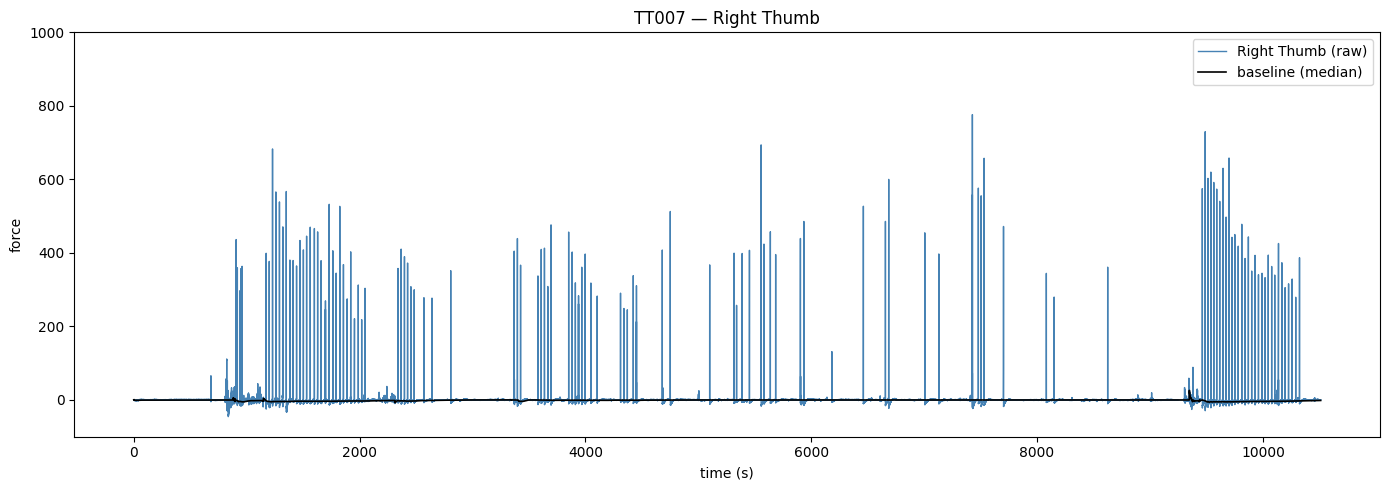

In [485]:
plot_channel(SUBJECT, CHANNEL, x, t, med, sigma, t0=0.0, duration=200*60, ymin=-100.0, ymax=1000.0,
             high_thresh=K_HIGH, low_thresh=K_LOW, show_signal=True, show_baseline=True )

In [486]:
presses, floor = detect_presses(t, x, med, sigma, K_HIGH, K_LOW,
                                 MIN_DURATION, MAX_DURATION, REFRACTORY,
                                 session_starts=session_starts, floor_max=FLOOR_MAX,
                                 floor_min=FLOOR_MIN, quiet_s=QUIET_S,
                                 decay_rate=DECAY_RATE, rise_frac=RISE_FRAC,
                                 rise_alpha=RISE_ALPHA, exclusion_intervals=exclusion_intervals)
n_ok = sum(not p["rejected"] for p in presses)
print(f"{len(presses)} candidate presses ({n_ok} accepted, {len(presses) - n_ok} rejected: too long)")


# # Manual scoring
# scoring_path = DATA_ROOT / SUBJECT / "Scoring_Pingouin" / f"{SUBJECT}_force_scoring.csv"
# manual_scoring = pd.read_csv(scoring_path, index_col=0)
# manual_presses = manual_scoring[manual_scoring["channel"] == CHANNEL]
# print(f"{len(manual_presses)} manually annotated presses for {CHANNEL}")

175 candidate presses (173 accepted, 2 rejected: too long)


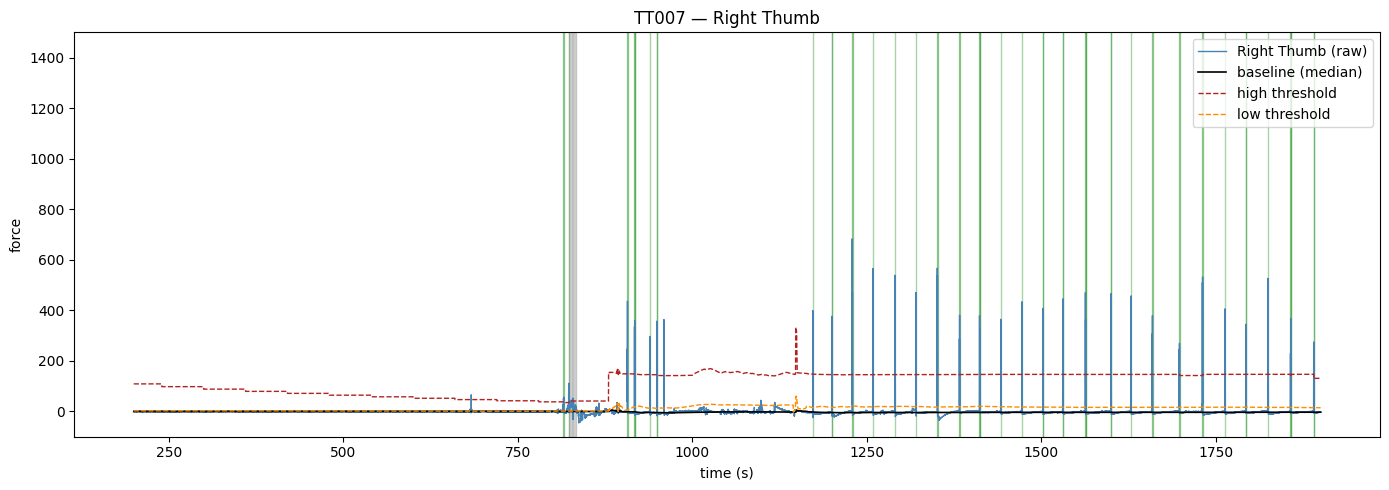

In [487]:
plot_channel(SUBJECT, CHANNEL, x, t, med, sigma, t0=200.0, duration=1700, ymin=-100.0, ymax=1500.0,
            high_thresh=K_HIGH, low_thresh=K_LOW, floor=floor, show_baseline=True , show_thresholds=True, show_presses_auto=True, 
            presses=presses, show_signal=True)


In [488]:
# plot_channel(SUBJECT, CHANNEL, x, t, med, sigma, t0=10160.0, duration=200, ymin=-100.0, ymax=1200.0,
#             high_thresh=K_HIGH, low_thresh=K_LOW, floor=floor, show_signal=True, show_baseline=True , show_thresholds=True, 
#             show_presses_manual=True, manual_presses=manual_presses)

## 4. Export for the GUI 
Pink overlay in Scoring_Pingouin_Claude_V4.py

In [489]:
auto_out_dir = DATA_ROOT / "Scoring_Pingouin"
auto_out_dir.mkdir(exist_ok=True)
auto_out_path = auto_out_dir / f"{SUBJECT}_auto_presses.csv"

auto_df = pd.DataFrame([{
    "channel": CHANNEL,
    "onset_absolute": p["onset_t"],
    "offset_absolute": p["offset_t"],
    "peak_amp": p["peak_amp"],
    "rejected": p["rejected"],
} for p in presses])

# Merge every event with any event(s) happening less than 4 seconds after it
auto_df_merged = merge_close_events(auto_df, gap_s=4.0)

auto_df.to_csv(auto_out_path, index=False)
print(f"{len(auto_df)} detections exported -> {auto_out_path}")

auto_df_merged 

175 detections exported -> C:\Users\eva\Documents\Master\ICM\Ilo\Scoring_Pingouin\TT007_auto_presses.csv


,channel,onset_absolute,offset_absolute,peak_amp,rejected
0,Right Thumb,815.470,816.354,57.147331,False
1,Right Thumb,822.842,827.410,111.481407,True
2,Right Thumb,829.810,833.312,42.080906,True
3,Right Thumb,906.826,907.362,436.321625,False
4,Right Thumb,917.168,917.632,359.522003,False
...,...,...,...,...,...
117,Right Thumb,10196.554,10197.066,305.480469,False
118,Right Thumb,10227.240,10227.780,315.907043,False
119,Right Thumb,10258.906,10259.422,328.983704,False
120,Right Thumb,10290.554,10291.082,279.378387,False


# Create csv Subject TT001
Runs detection on **both** channels of interest for `SUBJECT` (the Response channel and the Reset
channel, looked up from `Subjects.csv`), using the same tuned parameters as above.

- `{SUBJECT}_auto_presses.csv` is overwritten with detections from **both** channels (instead of
  just `CHANNEL`), so the existing pink "AUTO" overlay in Scoring_Pingouin_Claude_V4.py (key `d` /
  button `[3] AUTO`) shows both on their respective signal rows -- no GUI changes needed.
- `{SUBJECT}_events_auto.csv` is filled with one row per confirmed press (rejected/too-long
  candidates dropped, close re-triggers merged), labelled `event` = "Response"/"Reset" depending on
  which channel it came from, matching the manual `{SUBJECT}_events.csv` schema closely enough to
  compare the two.


In [546]:
# Self-contained: recompute vhdr_path / session_starts / exclusion_intervals for the CURRENT
# SUBJECT here rather than reusing the globals from cell 2 above. Those are only refreshed when
# that earlier cell is re-run, so if SUBJECT was changed without re-running it, this section would
# silently detect on the *previous* subject's signal while still writing files named after the new
# one (that's what produced TT001_auto_presses.csv full of TT007 detections).
SUBJECT = "TT011"
vhdr_path = DATA_ROOT / SUBJECT / f"{SUBJECT}.vhdr"
_, _, fs = load_channel(vhdr_path, CHANNEL)
session_starts = load_session_starts(vhdr_path, fs)
exclusion_intervals = load_exclusion_intervals(vhdr_path, fs)
print(f"{SUBJECT}: {len(session_starts)} session start(s), {len(exclusion_intervals)} exclusion window(s)")

subjects_path = DATA_ROOT / "Scoring_Pingouin" / "Subjects.csv"
subjects_df = pd.read_csv(subjects_path)
subj_row = subjects_df.loc[subjects_df["Subject"] == SUBJECT]
if subj_row.empty:
    raise ValueError(f"{SUBJECT} not found in {subjects_path}")
subj_row = subj_row.iloc[0]

channels_of_interest = {"Response": subj_row["Response"], "Reset": subj_row["Reset"]}
print(f"{SUBJECT}: {channels_of_interest}")

TT011: 8 session start(s), 30 exclusion window(s)
TT011: {'Response': 'Left Thumb', 'Reset': 'Right Thumb'}


In [547]:
per_channel_auto = {}    # event -> raw detections (one row per candidate, incl. rejected)
per_channel_merged = {}  # event -> confirmed detections, close re-triggers merged
incr = 0
for event_label, ch in channels_of_interest.items():
    ct, cx, cfs = load_channel(vhdr_path, ch)
    c_med, c_sigma = rolling_baseline(cx, cfs, BASELINE_WINDOW_S, t=ct, session_starts=session_starts)
    c_presses, _ = detect_presses(ct, cx, c_med, c_sigma, K_HIGH, K_LOW,
                                   MIN_DURATION, MAX_DURATION, REFRACTORY,
                                   session_starts=session_starts, floor_max=FLOOR_MAX,
                                   floor_min=FLOOR_MIN + incr, quiet_s=QUIET_S,
                                   decay_rate=DECAY_RATE, rise_frac=RISE_FRAC,
                                   rise_alpha=RISE_ALPHA, exclusion_intervals=exclusion_intervals)

    c_auto_df = pd.DataFrame([{
        "channel": ch,
        "onset_absolute": p["onset_t"],
        "offset_absolute": p["offset_t"],
        "peak_amp": p["peak_amp"],
        "rejected": p["rejected"],
    } for p in c_presses])
    per_channel_auto[event_label] = c_auto_df

    confirmed = c_auto_df[~c_auto_df["rejected"]] if not c_auto_df.empty else c_auto_df
    merged = merge_close_events(confirmed, gap_s=5.0)
    merged["event"] = event_label
    per_channel_merged[event_label] = merged
    incr = 100

    print(f"{event_label:<8} ({ch:<20}): {len(c_presses)} candidate(s) -> "
          f"{len(confirmed)} confirmed -> {len(merged)} after merge")

# Both channels together -> overwrite {SUBJECT}_auto_presses.csv so the GUI's pink overlay
# (already multi-channel aware) shows detections on both signal rows.
auto_out_path = auto_out_dir / f"{SUBJECT}_auto_presses.csv"
auto_presses_df = pd.concat(per_channel_auto.values(), ignore_index=True).sort_values("onset_absolute").reset_index(drop=True)
auto_presses_df.to_csv(auto_out_path, index=False)
print(f"\n{len(auto_presses_df)} detections (both channels) exported -> {auto_out_path}")


Response (Left Thumb          ): 265 candidate(s) -> 265 confirmed -> 151 after merge
Reset    (Right Thumb         ): 73 candidate(s) -> 73 confirmed -> 30 after merge

338 detections (both channels) exported -> C:\Users\eva\Documents\Master\ICM\Ilo\Scoring_Pingouin\TT011_auto_presses.csv


In [548]:
merged_df = pd.concat(per_channel_merged.values(), ignore_index=True) \
              .sort_values("onset_absolute").reset_index(drop=True)

merged_df["subject"] = SUBJECT
merged_df["session"] = label_sessions(merged_df["onset_absolute"], session_starts)
merged_df["onset_s"] = merged_df["onset_absolute"].round(4)
merged_df["offset_s"] = merged_df["offset_absolute"].round(4)
merged_df["duration_s"] = (merged_df["offset_s"] - merged_df["onset_s"]).round(4)
merged_df["time_since_last_event"] = merged_df["onset_s"].diff().round(4)

events_auto_df = merged_df[["subject", "session", "event", "channel",
                             "onset_s", "offset_s", "duration_s"]]

events_auto_path = DATA_ROOT / "Scoring_Pingouin" / f"{SUBJECT}_events_auto.csv"
events_auto_df.to_csv(events_auto_path, index=False)
print(f"{len(events_auto_df)} events exported -> {events_auto_path}")

events_auto_df


181 events exported -> C:\Users\eva\Documents\Master\ICM\Ilo\Scoring_Pingouin\TT011_events_auto.csv


,subject,session,event,channel,onset_s,offset_s,duration_s
0,TT011,pre-session,Reset,Right Thumb,938.070,938.244,0.174
1,TT011,Session 3,Response,Left Thumb,1143.606,1144.200,0.594
2,TT011,Session 3,Response,Left Thumb,1152.032,1152.906,0.874
3,TT011,Session 3,Reset,Right Thumb,1156.870,1158.006,1.136
4,TT011,Session 3,Response,Left Thumb,1167.556,1168.060,0.504
...,...,...,...,...,...,...,...
176,TT011,Session 8,Response,Left Thumb,11403.376,11403.968,0.592
177,TT011,Session 8,Response,Left Thumb,11433.886,11434.450,0.564
178,TT011,Session 8,Response,Left Thumb,11478.422,11478.598,0.176
179,TT011,Session 8,Response,Left Thumb,11519.118,11519.632,0.514
